# SDR Linkbudget (Student)

Aufgaben:
1. Traeger um 433 MHz messen.
2. Mit `../03_02_LABOR-2/calibration.json` die Empfangsleistung bestimmen.
3. Bei 0 dBi Sende-/Empfangsantenne C/N0 berechnen.
4. Aus Noise Floor die effektive Rauschtemperatur ableiten.
5. LOS-Freiraumdaempfung aus geschaetztem Abstand und Wellenlaenge berechnen.
6. Mit gemessener Empfangsleistung (bei bekannter Sendeleistung) vergleichen und Multipath diskutieren.

Hinweis: Die TODO-Stellen sind Platzhalter. Das Notebook laeuft trotzdem fehlerfrei.

In [9]:
import math
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

LAB_DIR = Path.cwd()
CAL_PATH = LAB_DIR.parent / "03_02_LABOR-2" / "calibration.json"

# Bekannt gegebene Sendeleistung (vom Versuchsaufbau)
TX_POWER_DBM = 10.0

# TODO: am Geraet gemessene/gesetzte Traegerfrequenz einsetzen
carrier_freq_hz = 433.92e6

# TODO: geschaetzten Abstand Sender-Empfaenger einsetzen
distance_guess_m = 1000.0

print("Calibration file:", CAL_PATH)

Calibration file: C:\_git\KT_course\lab_suite\labs\03_03_LABOR-3\03_02_LABOR-2\calibration.json


In [12]:
# Kalibrierung laden (wird fuer echte Messung benoetigt)
CAL_PATH = Path(r"C:\_git\KT_course\lab_suite\labs\03_02_LABOR-2\submissions\calibration.json")
cal = json.loads(CAL_PATH.read_text(encoding="utf-8"))
print("Reference calibration frequency:", cal.get("reference_freq_hz", "n/a"), "Hz")
cal_offset_db = get_cal_offset_db(cal, GAIN_DB)

# TODO (Messung):
# - Spektrum um 433 MHz aufnehmen
# - Peak finden
# - Mit calibration_offset_dB auf dBm kalibrieren
# - Noise floor aus benachbarten Bins bestimmen

CENTER_FREQ_HZ = 433.9e6
SAMPLE_RATE_HZ = 2.048e6
GAIN_DB = 20.0
N = 4096
M = 32

# Bekannt gegebene Sendeleistung (anpassen falls noetig)
TX_POWER_DBM = -10.0 # tx power in dBm

# Geschaetzter LOS-Abstand (fuer Vergleich mit gemessener Linkdaempfung)
DIST_GUESS_M = 1.0 # distance in meter

def get_cal_offset_db(cal: dict, gain_db: float) -> float:
    gains = cal.get("gains", [])
    if not gains:
        raise ValueError("No gains in calibration file")
    best = min(gains, key=lambda g: abs(float(g["gain_dB"]) - float(gain_db)))
    return float(best["calibration_offset_dB"])

def capture_iq_or_fallback(center_hz: float, fs_hz: float, gain_db: float, total_samples: int) -> np.ndarray:
    try:
        from rtlsdr import RtlSdr
        sdr = RtlSdr()
        sdr.sample_rate = fs_hz
        sdr.center_freq = center_hz
        sdr.gain = gain_db
        iq = sdr.read_samples(total_samples)
        sdr.close()
        return np.asarray(iq, dtype=np.complex64)
    except Exception as ex:
        print("RTL-SDR nicht verfuegbar, nutze synthetischen Fallback:", ex)
        t = np.arange(total_samples, dtype=np.float64) / fs_hz
        tone_off_hz = 70e3
        tone = 0.08 * np.exp(1j * 2 * np.pi * tone_off_hz * t)
        noise = (np.random.randn(total_samples) + 1j * np.random.randn(total_samples)) * 0.01
        return (tone + noise).astype(np.complex64)

def avg_spectrum(iq: np.ndarray, fs_hz: float, nfft: int, m_avg: int):
    need = nfft * m_avg
    if iq.size < need:
        raise ValueError(f"Need {need} samples, got {iq.size}")
    x = iq[:need].reshape(m_avg, nfft)
    win = np.hanning(nfft).astype(np.float64)
    spec = np.fft.fftshift(np.fft.fft(x * win, axis=1), axes=1)
    mag = np.mean(np.abs(spec), axis=0)
    mag_db = 20.0 * np.log10(np.maximum(mag, 1e-15))
    f_rel = np.fft.fftshift(np.fft.fftfreq(nfft, d=1.0 / fs_hz))
    return f_rel, mag_db

def estimate_noise_db(mag_db: np.ndarray, peak_idx: int, guard: int = 4) -> float:
    mask = np.ones_like(mag_db, dtype=bool)
    lo = max(0, peak_idx - guard)
    hi = min(mag_db.size, peak_idx + guard + 1)
    mask[lo:hi] = False
    return float(np.median(mag_db[mask]))

# Spektrum aufnehmen
iq = capture_iq_or_fallback(CENTER_FREQ_HZ, SAMPLE_RATE_HZ, GAIN_DB, N * M)
f_rel_hz, mag_db_raw = avg_spectrum(iq, SAMPLE_RATE_HZ, N, M)

# Peak finden
peak_idx = int(np.argmax(mag_db_raw))
carrier_off_hz = float(f_rel_hz[peak_idx])
carrier_freq_hz = CENTER_FREQ_HZ + carrier_off_hz

# Kalibrierte Traegerleistung
rx_power_dbm = float(mag_db_raw[peak_idx] + cal_offset_db)

# Noise Floor aus gemitteltem Spektrum
noise_bin_dbm = estimate_noise_db(mag_db_raw) + cal_offset_db

# Bin-Bandbreite
bin_bw_hz = SAMPLE_RATE_HZ / N

# Platzhalterwerte (damit Notebook laeuft)
#rx_power_dbm = -95.0
#noise_bin_dbm = -120.0
#bin_bw_hz = 500.0

print(f"RX power placeholder      : {rx_power_dbm:.2f} dBm")
print(f"Noise floor placeholder   : {noise_bin_dbm:.2f} dBm / bin")
print(f"Bin bandwidth placeholder : {bin_bw_hz:.2f} Hz")

Reference calibration frequency: 434000000.0 Hz
RTL-SDR nicht verfuegbar, nutze synthetischen Fallback: Error loading librtlsdr. Make sure librtlsdr (and all of its dependencies) are in your path


TypeError: estimate_noise_db() missing 1 required positional argument: 'peak_idx'

In [4]:
# C/N0 und effektive Rauschtemperatur

# TODO: N0 aus Noise-Bin auf dBm/Hz normieren
n0_dbm_hz = noise_bin_dbm - 10.0 * math.log10(bin_bw_hz)

# TODO: C/N0 = C - N0
cn0_db_hz = rx_power_dbm - n0_dbm_hz

# TODO: T_eff aus N0 ableiten, Referenz -174 dBm/Hz bei 290 K
t_eff_k = 290.0 * 10.0 ** ((n0_dbm_hz + 174.0) / 10.0)

print(f"N0                : {n0_dbm_hz:.2f} dBm/Hz")
print(f"C/N0              : {cn0_db_hz:.2f} dB-Hz")
print(f"T_eff             : {t_eff_k:.1f} K")

N0                : -146.99 dBm/Hz
C/N0              : 51.99 dB-Hz
T_eff             : 145689.4 K


In [5]:
# Freiraumdaempfung (LOS) und Vergleich zur Messung

c0 = 299_792_458.0

# TODO: Wellenlaenge aus gemessener Traegerfrequenz
wavelength_m = c0 / carrier_freq_hz

# Gemessene Linkdaempfung bei 0 dBi / 0 dBi
fspl_meas_db = TX_POWER_DBM - rx_power_dbm

# TODO: theoretische LOS-Freiraumdaempfung mit geschaetztem Abstand
fspl_los_db = 20.0 * math.log10(4.0 * math.pi * distance_guess_m / wavelength_m)

# TODO: Differenz als Multipath-Indiz interpretieren
delta_db = fspl_meas_db - fspl_los_db

print(f"Wavelength        : {wavelength_m:.4f} m")
print(f"FSPL measured     : {fspl_meas_db:.2f} dB")
print(f"FSPL LOS (guess)  : {fspl_los_db:.2f} dB")
print(f"Delta             : {delta_db:+.2f} dB")

Wavelength        : 0.6909 m
FSPL measured     : 105.00 dB
FSPL LOS (guess)  : 85.20 dB
Delta             : +19.80 dB


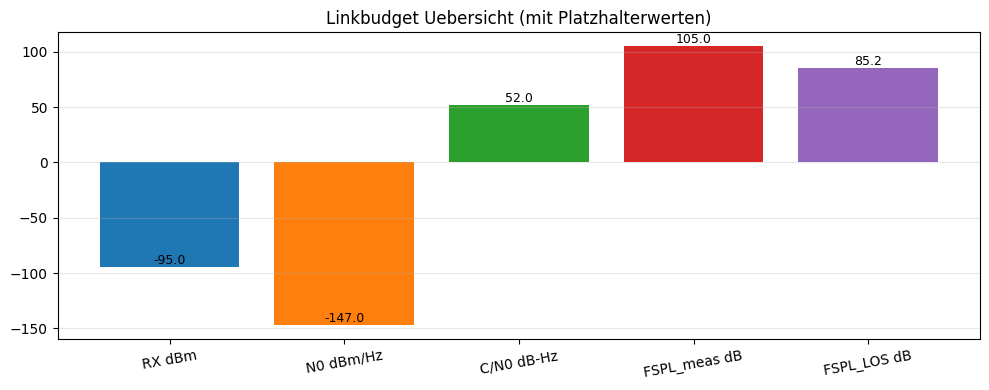

TODO: Platzhalterwerte durch reale Messwerte ersetzen.


In [6]:
# Einfache Visualisierung der wichtigsten Kennwerte
labels = ["RX dBm", "N0 dBm/Hz", "C/N0 dB-Hz", "FSPL_meas dB", "FSPL_LOS dB"]
values = [rx_power_dbm, n0_dbm_hz, cn0_db_hz, fspl_meas_db, fspl_los_db]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels, values, color=["C0", "C1", "C2", "C3", "C4"])
ax.set_title("Linkbudget Uebersicht (mit Platzhalterwerten)")
ax.grid(True, axis="y", alpha=0.3)
for i, v in enumerate(values):
    ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print("TODO: Platzhalterwerte durch reale Messwerte ersetzen.")